In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew

print("Setup completed.")

Mounted at /content/drive
Setup completed.


In [2]:
BASE_DIR = "/content/drive/MyDrive/気合のCOVID19"

PATIENT_CSV = os.path.join(
    BASE_DIR,
    "00_共通・研究管理",
    "02_データ定義・元データ",
    "患者データファイル.csv"
)

SPLIT_CSV = os.path.join(
    BASE_DIR,
    "00_共通・研究管理",
    "03_患者選定",
    "COVID19_固定患者split_1277.csv"
)

print("Patient file exists:", os.path.exists(PATIENT_CSV))
print("Split file exists:", os.path.exists(SPLIT_CSV))

patient_df = pd.read_csv(PATIENT_CSV)
split_df = pd.read_csv(SPLIT_CSV)

print("patient_df:", patient_df.shape)
print("split_df:", split_df.shape)

Patient file exists: True
Split file exists: True
patient_df: (1384, 131)
split_df: (1277, 5)


In [3]:
clinical_df = patient_df.merge(
    split_df[["Subject ID", "true_label", "split"]],
    left_on="to_patient_id",
    right_on="Subject ID",
    how="inner",
    validate="one_to_one"
)

print("clinical_df:", clinical_df.shape)

print("\n=== split ===")
print(clinical_df["split"].value_counts())

print("\n=== split × outcome ===")
print(
    pd.crosstab(
        clinical_df["split"],
        clinical_df["true_label"]
    )
)

clinical_df: (1277, 134)

=== split ===
split
train    1021
test      128
val       128
Name: count, dtype: int64

=== split × outcome ===
true_label    0    1
split               
test        111   17
train       886  135
val         111   17


In [4]:
FINAL_RAW_VARIABLES = {
    "age": "age.splits",
    "sex": "gender_concept_name",
    "hf": "hf_ef_v",
    "spo2": "59408-5_Oxygen saturation in Arterial blood by Pulse oximetry",
    "rr": "9279-1_Respiratory rate",
    "lymph": "731-0_Lymphocytes [#/volume] in Blood by Automated count",
    "egfr": "62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)",
    "crp": "1988-5_C reactive protein [Mass/volume] in Serum or Plasma",
    "lactate": "2524-7_Lactate [Moles/volume] in Serum or Plasma"
}

# 必要列がすべて存在するか確認
missing_columns = [
    raw_col
    for raw_col in FINAL_RAW_VARIABLES.values()
    if raw_col not in clinical_df.columns
]

assert len(missing_columns) == 0, \
    f"存在しない列があります: {missing_columns}"

model_df = clinical_df[
    ["Subject ID", "true_label", "split"]
    + list(FINAL_RAW_VARIABLES.values())
].copy()

# 短い列名へ変更
rename_map = {
    raw_col: short_name
    for short_name, raw_col in FINAL_RAW_VARIABLES.items()
}

model_df = model_df.rename(columns=rename_map)

print("model_df:", model_df.shape)
display(model_df.head())

model_df: (1277, 12)


,Subject ID,true_label,split,age,sex,hf,spo2,rr,lymph,egfr,crp,lactate
0,A917122,0,train,"(74,90]",FEMALE,NaN,91.0,22.0,0.43,35.0,3.4,0.9
1,A387558,1,test,"(74,90]",MALE,NaN,100.0,39.0,NaN,56.0,25.3,5.6
2,A968238,1,train,"(74,90]",MALE,No,84.0,42.0,0.72,49.0,9.1,2.2
3,A300871,1,train,"(74,90]",FEMALE,HFrEF,97.0,20.0,NaN,NaN,NaN,NaN
4,A642300,1,test,"(74,90]",FEMALE,HFrEF,90.0,26.0,NaN,13.0,17.7,2.4


In [6]:
# split名を確認
print(model_df["split"].value_counts(dropna=False))

train_df = model_df[
    model_df["split"] == "train"
].copy()

val_df = model_df[
    model_df["split"] == "val"
].copy()

test_df = model_df[
    model_df["split"] == "test"
].copy()

print("\nTrain:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain deaths:", int(train_df["true_label"].sum()))

split
train    1021
test      128
val       128
Name: count, dtype: int64

Train: (1021, 12)
Val  : (128, 12)
Test : (128, 12)

Train deaths: 135


In [7]:
CONTINUOUS_VARS = [
    "spo2",
    "rr",
    "lymph",
    "egfr",
    "crp",
    "lactate"
]

distribution_rows = []

for col in CONTINUOUS_VARS:
    x = train_df[col].dropna().astype(float)

    distribution_rows.append({
        "variable": col,
        "n_observed": len(x),
        "n_missing": train_df[col].isna().sum(),
        "missing_rate": train_df[col].isna().mean(),
        "min": x.min(),
        "Q1": x.quantile(0.25),
        "median": x.median(),
        "mean": x.mean(),
        "Q3": x.quantile(0.75),
        "max": x.max(),
        "skew_raw": skew(x),
        "skew_log1p": skew(np.log1p(x))
    })

distribution_check = pd.DataFrame(distribution_rows)

display(
    distribution_check.round(4)
)

,variable,n_observed,n_missing,missing_rate,min,Q1,median,mean,Q3,max,skew_raw,skew_log1p
0,spo2,1018,3,0.0029,61.00,92.00,95.00,93.7839,97.0000,100.00,-2.0971,-2.4548
1,rr,1019,2,0.0020,11.00,17.00,20.00,21.9195,24.0000,95.00,3.0631,1.4496
2,lymph,732,289,0.2831,0.05,0.68,0.94,1.0690,1.3125,4.97,1.8590,0.6238
3,egfr,859,162,0.1587,3.00,57.00,86.00,80.8789,107.0000,120.00,-0.5609,-2.0054
4,crp,793,228,0.2233,0.10,3.40,8.40,10.7303,15.4000,51.00,1.2175,-0.4271
5,lactate,773,248,0.2429,0.50,1.10,1.50,1.8406,2.0000,20.00,6.5372,2.2693


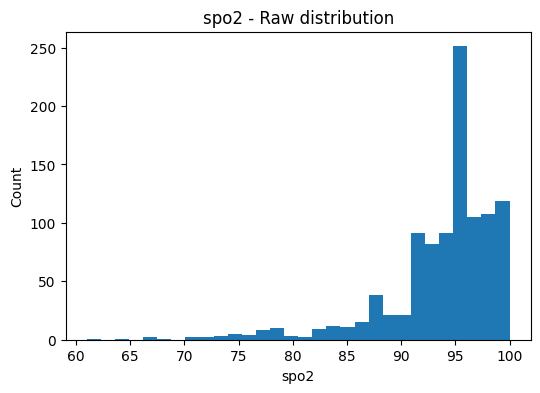

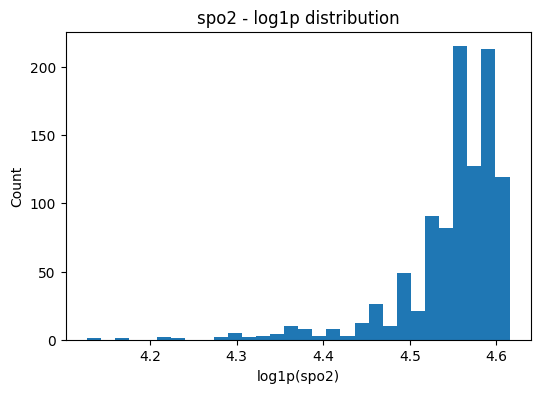

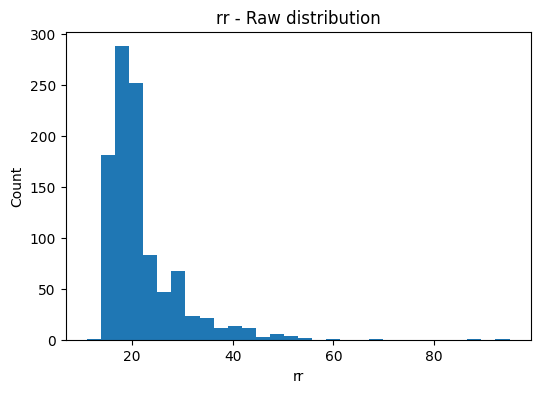

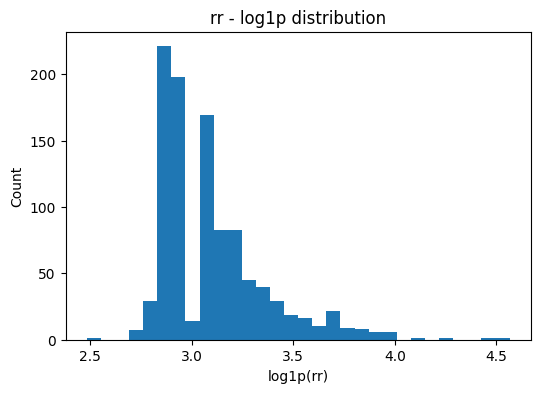

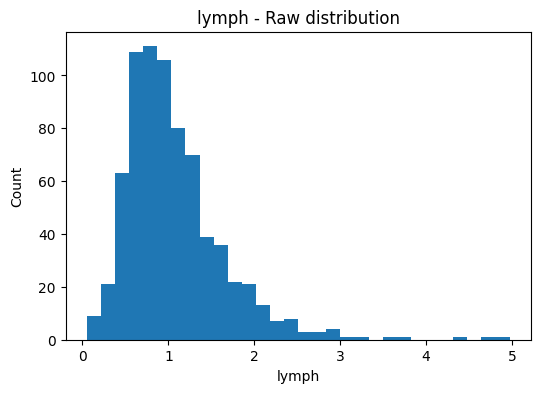

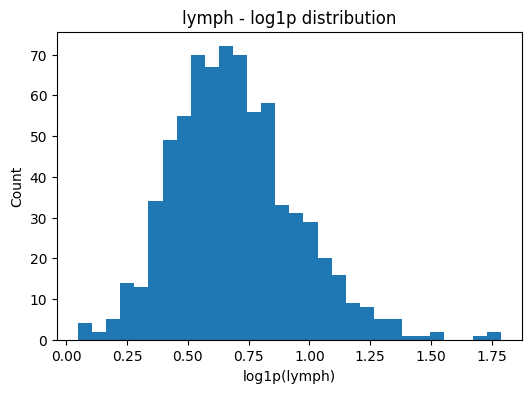

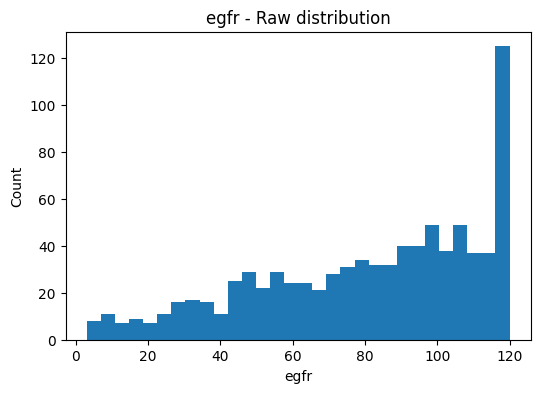

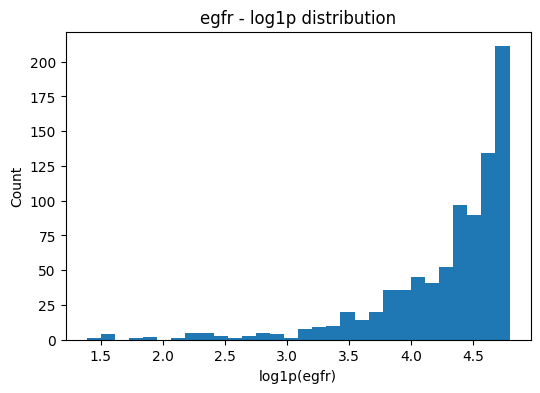

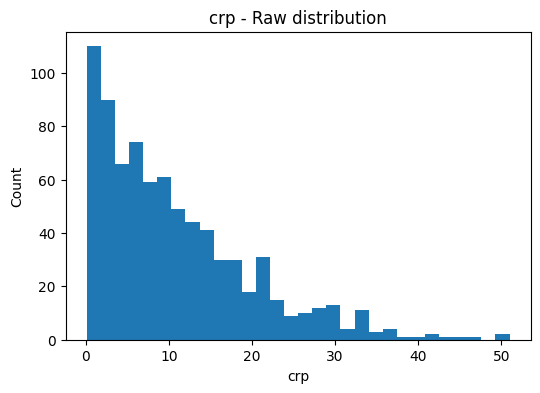

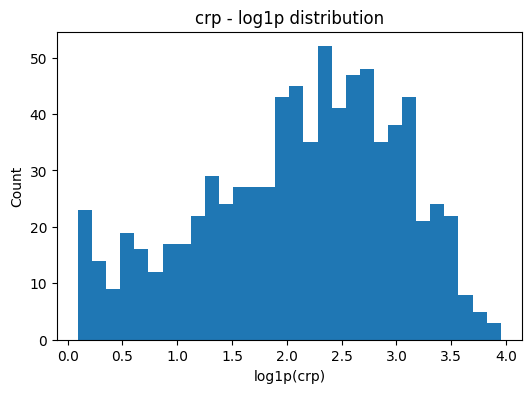

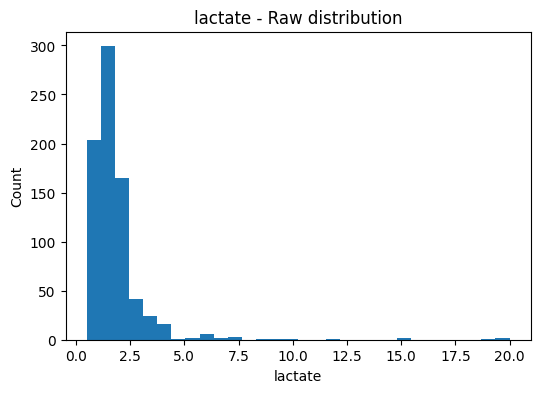

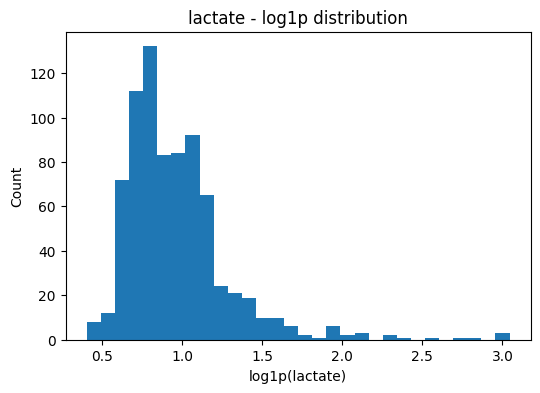

In [8]:
for col in CONTINUOUS_VARS:

    x = train_df[col].dropna().astype(float)

    plt.figure(figsize=(6, 4))
    plt.hist(x, bins=30)
    plt.title(f"{col} - Raw distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(np.log1p(x), bins=30)
    plt.title(f"{col} - log1p distribution")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Count")
    plt.show()

In [9]:
from sklearn.impute import SimpleImputer

CONTINUOUS_VARS = [
    "spo2",
    "rr",
    "lymph",
    "egfr",
    "crp",
    "lactate"
]

# Trainだけで中央値を学習
continuous_imputer = SimpleImputer(strategy="median")

train_cont = continuous_imputer.fit_transform(
    train_df[CONTINUOUS_VARS]
)

val_cont = continuous_imputer.transform(
    val_df[CONTINUOUS_VARS]
)

test_cont = continuous_imputer.transform(
    test_df[CONTINUOUS_VARS]
)

# DataFrameへ戻す
train_cont = pd.DataFrame(
    train_cont,
    columns=CONTINUOUS_VARS,
    index=train_df.index
)

val_cont = pd.DataFrame(
    val_cont,
    columns=CONTINUOUS_VARS,
    index=val_df.index
)

test_cont = pd.DataFrame(
    test_cont,
    columns=CONTINUOUS_VARS,
    index=test_df.index
)

print("=== Train-derived medians ===")
for col, median in zip(
    CONTINUOUS_VARS,
    continuous_imputer.statistics_
):
    print(f"{col}: {median}")

print("\nMissing after imputation")
print("Train:", train_cont.isna().sum().sum())
print("Val  :", val_cont.isna().sum().sum())
print("Test :", test_cont.isna().sum().sum())

=== Train-derived medians ===
spo2: 95.0
rr: 20.0
lymph: 0.94
egfr: 86.0
crp: 8.4
lactate: 1.5

Missing after imputation
Train: 0
Val  : 0
Test : 0


In [10]:
LOG1P_VARS = [
    "lymph",
    "crp",
    "lactate"
]

NO_LOG_VARS = [
    "spo2",
    "rr",
    "egfr"
]

for col in LOG1P_VARS:
    train_cont[col] = np.log1p(train_cont[col])
    val_cont[col] = np.log1p(val_cont[col])
    test_cont[col] = np.log1p(test_cont[col])

print("log1p applied to:", LOG1P_VARS)
print("No log transform :", NO_LOG_VARS)

display(train_cont.head())

log1p applied to: ['lymph', 'crp', 'lactate']
No log transform : ['spo2', 'rr', 'egfr']


,spo2,rr,lymph,egfr,crp,lactate
0,91.0,22.0,0.357674,35.0,1.481605,0.641854
2,84.0,42.0,0.542324,49.0,2.312535,1.163151
3,97.0,20.0,0.662688,86.0,2.240710,0.916291
5,98.0,20.0,0.783902,98.0,2.341806,0.832909
6,97.0,40.0,0.620576,83.0,2.240710,0.916291


In [ ]:
from sklearn.preprocessing import StandardScaler

continuous_scaler = StandardScaler()

# Trainで平均・標準偏差を学習
train_cont_scaled = continuous_scaler.fit_transform(train_cont)

# 同じScalerをVal/Testへ適用
val_cont_scaled = continuous_scaler.transform(val_cont)
test_cont_scaled = continuous_scaler.transform(test_cont)

train_cont_scaled = pd.DataFrame(
    train_cont_scaled,
    columns=CONTINUOUS_VARS,
    index=train_df.index
)

val_cont_scaled = pd.DataFrame(
    val_cont_scaled,
    columns=CONTINUOUS_VARS,
    index=val_df.index
)

test_cont_scaled = pd.DataFrame(
    test_cont_scaled,
    columns=CONTINUOUS_VARS,
    index=test_df.index
)

print("=== Train scaling parameters ===")

scaling_params = pd.DataFrame({
    "variable": CONTINUOUS_VARS,
    "mean_after_log_if_applicable": continuous_scaler.mean_,
    "std_after_log_if_applicable": continuous_scaler.scale_
})

display(scaling_params)

print("\n=== Check Train after scaling ===")
display(
    train_cont_scaled.agg(["mean", "std"]).T
)

In [12]:
from sklearn.preprocessing import StandardScaler

continuous_scaler = StandardScaler()

# Trainで平均・標準偏差を学習
train_cont_scaled = continuous_scaler.fit_transform(train_cont)

# 同じScalerをVal/Testへ適用
val_cont_scaled = continuous_scaler.transform(val_cont)
test_cont_scaled = continuous_scaler.transform(test_cont)

train_cont_scaled = pd.DataFrame(
    train_cont_scaled,
    columns=CONTINUOUS_VARS,
    index=train_df.index
)

val_cont_scaled = pd.DataFrame(
    val_cont_scaled,
    columns=CONTINUOUS_VARS,
    index=val_df.index
)

test_cont_scaled = pd.DataFrame(
    test_cont_scaled,
    columns=CONTINUOUS_VARS,
    index=test_df.index
)

print("=== Train scaling parameters ===")

scaling_params = pd.DataFrame({
    "variable": CONTINUOUS_VARS,
    "mean_after_log_if_applicable": continuous_scaler.mean_,
    "std_after_log_if_applicable": continuous_scaler.scale_
})

display(scaling_params)

print("\n=== Check Train after scaling ===")
display(
    train_cont_scaled.agg(["mean", "std"]).T
)

=== Train scaling parameters ===


,variable,mean_after_log_if_applicable,std_after_log_if_applicable
0,spo2,93.787463,5.449517
1,rr,21.915769,7.681385
2,lymph,0.684422,0.215322
3,egfr,81.691479,28.708434
4,crp,2.142361,0.797838
5,lactate,0.955197,0.292280



=== Check Train after scaling ===


,mean,std
spo2,5.245559e-16,1.00049
rr,1.931201e-16,1.00049
lymph,1.774617e-16,1.00049
egfr,-1.948599e-16,1.00049
crp,-3.897198e-16,1.00049
lactate,-6.611318e-17,1.00049


In [13]:
from sklearn.preprocessing import OneHotEncoder

CATEGORICAL_VARS = [
    "age",
    "sex",
    "hf"
]

# 元データをコピー
train_cat = train_df[CATEGORICAL_VARS].copy()
val_cat = val_df[CATEGORICAL_VARS].copy()
test_cat = test_df[CATEGORICAL_VARS].copy()

# -------------------------
# sex: Train最頻値で補完
# -------------------------
sex_mode = train_cat["sex"].mode(dropna=True)[0]

train_cat["sex"] = train_cat["sex"].fillna(sex_mode)
val_cat["sex"] = val_cat["sex"].fillna(sex_mode)
test_cat["sex"] = test_cat["sex"].fillna(sex_mode)

# -------------------------
# hf: Missingカテゴリとして保持
# -------------------------
train_cat["hf"] = train_cat["hf"].fillna("Missing")
val_cat["hf"] = val_cat["hf"].fillna("Missing")
test_cat["hf"] = test_cat["hf"].fillna("Missing")

print("Train-derived sex mode:", sex_mode)

print("\n=== Train category counts ===")
for col in CATEGORICAL_VARS:
    print(f"\n[{col}]")
    print(train_cat[col].value_counts(dropna=False))

Train-derived sex mode: MALE

=== Train category counts ===

[age]
age
[18,59]    544
(59,74]    276
(74,90]    201
Name: count, dtype: int64

[sex]
sex
MALE      581
FEMALE    440
Name: count, dtype: int64

[hf]
hf
No         775
Missing    189
HFpEF       36
HFrEF       21
Name: count, dtype: int64


In [14]:
# drop='first' で基準カテゴリを1つ落とす
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

train_cat_encoded = encoder.fit_transform(train_cat)
val_cat_encoded = encoder.transform(val_cat)
test_cat_encoded = encoder.transform(test_cat)

encoded_columns = encoder.get_feature_names_out(CATEGORICAL_VARS)

train_cat_encoded = pd.DataFrame(
    train_cat_encoded,
    columns=encoded_columns,
    index=train_cat.index
)

val_cat_encoded = pd.DataFrame(
    val_cat_encoded,
    columns=encoded_columns,
    index=val_cat.index
)

test_cat_encoded = pd.DataFrame(
    test_cat_encoded,
    columns=encoded_columns,
    index=test_cat.index
)

print("=== Encoded columns ===")
print(list(encoded_columns))

print("\nShapes")
print("Train:", train_cat_encoded.shape)
print("Val  :", val_cat_encoded.shape)
print("Test :", test_cat_encoded.shape)

display(train_cat_encoded.head())

=== Encoded columns ===
['age_(74,90]', 'age_[18,59]', 'sex_MALE', 'hf_HFrEF', 'hf_Missing', 'hf_No']

Shapes
Train: (1021, 6)
Val  : (128, 6)
Test : (128, 6)


,"age_(74,90]","age_[18,59]",sex_MALE,hf_HFrEF,hf_Missing,hf_No
0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,1.0,0.0


In [15]:
# カテゴリとreferenceを明示的に固定
encoder = OneHotEncoder(
    categories=[
        ["[18,59]", "(59,74]", "(74,90]"],   # age
        ["FEMALE", "MALE"],                  # sex
        ["No", "HFpEF", "HFrEF", "Missing"] # hf
    ],
    drop=[
        "[18,59]",   # age reference
        "FEMALE",    # sex reference
        "No"         # hf reference
    ],
    handle_unknown="ignore",
    sparse_output=False
)

train_cat_encoded = encoder.fit_transform(train_cat)
val_cat_encoded = encoder.transform(val_cat)
test_cat_encoded = encoder.transform(test_cat)

encoded_columns = encoder.get_feature_names_out(CATEGORICAL_VARS)

train_cat_encoded = pd.DataFrame(
    train_cat_encoded,
    columns=encoded_columns,
    index=train_cat.index
)

val_cat_encoded = pd.DataFrame(
    val_cat_encoded,
    columns=encoded_columns,
    index=val_cat.index
)

test_cat_encoded = pd.DataFrame(
    test_cat_encoded,
    columns=encoded_columns,
    index=test_cat.index
)

print("=== Reference categories ===")
print("age : [18,59]")
print("sex : FEMALE")
print("hf  : No")

print("\n=== Encoded columns ===")
print(list(encoded_columns))

print("\nShapes")
print("Train:", train_cat_encoded.shape)
print("Val  :", val_cat_encoded.shape)
print("Test :", test_cat_encoded.shape)

=== Reference categories ===
age : [18,59]
sex : FEMALE
hf  : No

=== Encoded columns ===
['age_(59,74]', 'age_(74,90]', 'sex_MALE', 'hf_HFpEF', 'hf_HFrEF', 'hf_Missing']

Shapes
Train: (1021, 6)
Val  : (128, 6)
Test : (128, 6)


In [16]:
# =========================================
# Cell 13: 最終LR入力12列を作成
# =========================================

# 連続6列 + カテゴリ6列
X_train = pd.concat(
    [train_cont_scaled, train_cat_encoded],
    axis=1
)

X_val = pd.concat(
    [val_cont_scaled, val_cat_encoded],
    axis=1
)

X_test = pd.concat(
    [test_cont_scaled, test_cat_encoded],
    axis=1
)

# 目的変数
y_train = train_df["true_label"].copy()
y_val = val_df["true_label"].copy()
y_test = test_df["true_label"].copy()

print("=== Final feature columns ===")
print(list(X_train.columns))

print("\nShapes")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny")
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\nMissing values")
print("Train:", X_train.isna().sum().sum())
print("Val  :", X_val.isna().sum().sum())
print("Test :", X_test.isna().sum().sum())

display(X_train.head())

=== Final feature columns ===
['spo2', 'rr', 'lymph', 'egfr', 'crp', 'lactate', 'age_(59,74]', 'age_(74,90]', 'sex_MALE', 'hf_HFpEF', 'hf_HFrEF', 'hf_Missing']

Shapes
X_train: (1021, 12)
X_val  : (128, 12)
X_test : (128, 12)

y
y_train: (1021,)
y_val  : (128,)
y_test : (128,)

Missing values
Train: 0
Val  : 0
Test : 0


,spo2,rr,lymph,egfr,crp,lactate,"age_(59,74]","age_(74,90]",sex_MALE,hf_HFpEF,hf_HFrEF,hf_Missing
0,-0.511506,0.010966,-1.517483,-1.626403,-0.828184,-1.072066,0.0,1.0,0.0,0.0,0.0,1.0
2,-1.796024,2.614663,-0.659931,-1.138741,0.213295,0.711486,0.0,1.0,1.0,0.0,0.0,0.0
3,0.589509,-0.249404,-0.100937,0.150079,0.123269,-0.133115,0.0,1.0,0.0,0.0,1.0,0.0
5,0.773011,-0.249404,0.462003,0.568074,0.249982,-0.418394,1.0,0.0,0.0,1.0,0.0,0.0
6,0.589509,2.354293,-0.296512,0.045580,0.123269,-0.133115,0.0,1.0,0.0,0.0,0.0,1.0


In [17]:
import os
import json

PREPROCESS_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "03_前処理"
)

os.makedirs(PREPROCESS_DIR, exist_ok=True)

feature_config = {
    "final_raw_variables": [
        "age",
        "sex",
        "hf",
        "spo2",
        "rr",
        "lymph",
        "egfr",
        "crp",
        "lactate"
    ],
    "final_model_columns": list(X_train.columns),
    "continuous_variables": CONTINUOUS_VARS,
    "categorical_variables": CATEGORICAL_VARS,
    "log1p_variables": LOG1P_VARS,
    "reference_categories": {
        "age": "[18,59]",
        "sex": "FEMALE",
        "hf": "No"
    },
    "sex_imputation_value": sex_mode,
    "fit_dataset": "train only",
    "n_features_after_encoding": X_train.shape[1]
}

config_path = os.path.join(
    PREPROCESS_DIR,
    "TaskB_LR_最終12列_前処理仕様.json"
)

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(feature_config, f, ensure_ascii=False, indent=2)

print("Saved:")
print(config_path)

Saved:
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/03_前処理/TaskB_LR_最終12列_前処理仕様.json
